# Pupila, locomoción y estado poblacional de VISp — análisis de **grupo**
### Allen Visual Coding – Neuropixels · DANDI:000021

*Cuaderno de expansión (multi-sujeto) del análisis de sesión única `04_pupila_estado_VISp.ipynb`.*

<div class="alert alert-success">
<b>Objetivos de aprendizaje</b><br>
Al terminar este cuaderno sabrás:<ul><li>Escanear un dandiset por <i>streaming</i> para encontrar todas las sesiones con seguimiento de pupila, y cachear la lista.</li><li>Encapsular un pipeline de neurociencia (streaming → QC → alineación con <code>pynapple</code> → PCA → correlación cruzada con nulo circular) en una <b>función por sesión</b> reutilizable.</li><li>Recorrer muchas sesiones con <code>tqdm</code>, cachear resultados y hacer <b>estadística de grupo</b>.</li><li>Controlar por <b>locomoción</b> (correlación parcial) para distinguir un efecto de la pupila de un efecto de la carrera.</li><li>Reforzar con un <b>decoder</b> (GLM lineal y GRU) del estado desde la pupila, la carrera y la pupila-sin-carrera, y compararlos a nivel de grupo.</li></ul>
</div>

## Resumen y motivación

En la sesión única `sub-738651046_ses-760693773` encontramos que **la pupila predecía el estado de VISp,
pero casi solo porque tanto la pupila como el cortex siguen a la locomoción**: la carrera dominaba el
estado (|r|≈0.76) y, al descontarla, el acoplamiento pupila↔estado se desplomaba (0.285 → 0.071, n.s.).

La pregunta ahora es de **generalización**:

> ¿Se cumple **en la población de ratones** que la pupila **no** indexa el estado poblacional de VISp
> *más allá* de la locomoción? ¿Y que la carrera **sí** lo domina de forma consistente?

Un solo animal es anecdótico; con muchas sesiones podemos hacer un **test de grupo** y convertir el
hallazgo descriptivo en una afirmación poblacional.

<div class="alert alert-info">
<b>Régimen: actividad espontánea</b><br>
Analizamos el <b>bloque espontáneo</b> (pantalla gris, luminancia constante), donde la lectura <i>pupila = arousal</i> es más limpia. El análisis con estímulo (<i>drifting gratings</i>) es una extensión opcional al final del cuaderno.
</div>

---
## 1. Configuración del entorno

In [1]:
# Requisitos (descomenta si hace falta instalarlos en tu entorno):
# %pip install dandi remfile h5py pynwb pynapple scikit-learn scipy tqdm pandas matplotlib

In [2]:
import warnings; warnings.filterwarnings("ignore")
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Streaming NWB / DANDI
import h5py, remfile, pynwb
from dandi.dandiapi import DandiAPIClient

# Series temporales, ML y estadistica
import pynapple as nap
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from scipy.stats import rankdata, wilcoxon, binomtest
from scipy.ndimage import gaussian_filter1d

# Deep learning (GRU del bloque de decoding)
import torch
import torch.nn as nn

# Barras de progreso (estilo databook)
from tqdm.auto import tqdm

print("Entorno cargado. Versiones clave:")
for n, m in [("numpy", np), ("pandas", pd), ("pynwb", pynwb), ("pynapple", nap)]:
    print(f"  {n:9s} {m.__version__}")

Entorno cargado. Versiones clave:
  numpy     2.4.6
  pandas    3.0.3
  pynwb     4.0.0
  pynapple  0.11.3


### 1.1 Parámetros centrales

In [3]:
# --- Dataset ---
DANDISET_ID      = "000021"
DANDISET_VERSION = "draft"
REGION           = "VISp"

# --- Rejilla temporal y QC (identicos a la sesion unica) ---
BIN          = 0.050
SMOOTH_SIGMA = 0.100
QC_QUALITY        = "good"
QC_ISI_MAX        = 0.5
QC_AMP_CUTOFF_MAX = 0.1
QC_PRESENCE_MIN   = 0.9

# --- Estado neuronal + correlacion ---
N_PCA        = 3
FRAC_TRAIN   = 0.70
LAG_MAX      = 3.0            # s (+/- rango de lags)
N_PERM       = 2000           # permutaciones circulares por acoplamiento
CORR_METHOD  = "spearman"
SEED         = 42

# --- Criterios de inclusion por sesion (PLAN A) ---
MIN_SPONT_MIN = 4.0
MIN_UNITS     = 30
MIN_UNITS_PCA = 5             # minimo absoluto para intentar PCA

# --- Decoding de refuerzo (GLM Ridge + GRU torch) ---
RUN_DECODING = True           # decodificar el estado desde pupila / carrera
RUN_GRU      = True           # False = solo GLM (mas rapido); util con muchas sesiones
TAU_GRID     = np.round(np.arange(-2.0, 2.0 + 1e-9, 0.25), 3)   # barrido de lag del decoder (s)
DEC_SEQ      = 20             # bins de pupila que ve la GRU (20 x 50 ms = 1 s)
GRU_HIDDEN, GRU_EPOCHS, GRU_LR, GRU_BATCH = 32, 80, 5e-3, 256

# --- Control del barrido de grupo ---
MAX_SESSIONS = None              # <-- SUBE este numero (o None) para procesar mas/todas las sesiones
SCAN_CSV     = "sessions_with_pupil_000021.csv"
RESULTS_CSV  = "grupo_espontaneo_resultados.csv"

np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Region={REGION} | bin={BIN*1000:.0f}ms | LAG_MAX=+/-{LAG_MAX}s | N_PERM={N_PERM}")
print(f"MAX_SESSIONS={MAX_SESSIONS} (None = todas) | decoding={RUN_DECODING} (GRU={RUN_GRU}) | device={DEVICE}")

Region=VISp | bin=50ms | LAG_MAX=+/-3.0s | N_PERM=2000
MAX_SESSIONS=None (None = todas) | decoding=True (GRU=True) | device=cuda


---
## 2. Encontrar las sesiones con pupila (escaneo + caché)

No todas las sesiones tienen seguimiento ocular. Escaneamos el dandiset comprobando **solo la estructura
HDF5** de cada fichero de sesión (sin descargar datos: es rapidísimo) para ver si contiene
`processing/filtered_gaze_mapping/pupil_area`. Cacheamos la lista en un CSV para escanear **una sola vez**.

<div class="alert alert-info">
<b>Metadatos, no datos</b><br>
<code>h5py</code> sobre <code>remfile</code> lee el <i>índice</i> del archivo remoto; comprobar si existe un objeto no descarga sus datos. Aun así, recorrer decenas de ficheros tarda unos minutos la primera vez — por eso cacheamos en <code>sessions_with_pupil_000021.csv</code>.
</div>

In [4]:
PUPIL_PATH = "processing/filtered_gaze_mapping/pupil_area"

def pupil_present(url):
    rem = remfile.File(url)
    with h5py.File(rem, "r") as f:
        return PUPIL_PATH in f

if os.path.exists(SCAN_CSV):
    df_sessions = pd.read_csv(SCAN_CSV)
    print(f"Lista cacheada: {len(df_sessions)} sesiones con pupila (desde {SCAN_CSV}).")
else:
    rows = []
    with DandiAPIClient() as client:
        dandiset = client.get_dandiset(DANDISET_ID, DANDISET_VERSION)
        # Solo ficheros de SESION: los de LFP por sonda llevan "probe-" y no tienen eye-tracking
        session_assets = [a for a in dandiset.get_assets()
                          if a.path.endswith(".nwb") and "probe-" not in a.path]
        print(f"Revisando {len(session_assets)} ficheros de sesion...")
        for a in tqdm(session_assets, desc="escaneando pupila"):
            url = a.get_content_url(follow_redirects=1, strip_query=True)
            try:
                if pupil_present(url):
                    m_sub = re.search(r"sub-([^_/]+)", a.path)
                    m_ses = re.search(r"ses-([^_/]+)", a.path)
                    rows.append({"subject": m_sub.group(1) if m_sub else None,
                                 "session": m_ses.group(1) if m_ses else None,
                                 "path": a.path, "asset_id": a.identifier, "url": url})
            except Exception as e:
                print(f"  ! error en {a.path}: {e}")
    df_sessions = pd.DataFrame(rows)
    df_sessions.to_csv(SCAN_CSV, index=False)
    print(f"{len(df_sessions)} sesiones con pupila. Guardadas en {SCAN_CSV}.")

display(df_sessions.head(10))

Lista cacheada: 26 sesiones con pupila (desde sessions_with_pupil_000021.csv).


,subject,session,path,asset_id,url
0,719817799,744228101.nwb,sub-719817799/sub-719817799_ses-744228101.nwb,eb36f94f-d6e7-45c6-aa02-7d4ed23453d3,https://dandiarchive.s3.amazonaws.com/blobs/11...
1,719828686,754312389.nwb,sub-719828686/sub-719828686_ses-754312389.nwb,5a58bf3d-a1b9-444b-8ab0-ef5478aa42a6,https://dandiarchive.s3.amazonaws.com/blobs/e1...
2,722882751,743475441.nwb,sub-722882751/sub-722882751_ses-743475441.nwb,522e8054-34ca-4579-ae80-350d0b24e0f4,https://dandiarchive.s3.amazonaws.com/blobs/c5...
3,723627600,742951821.nwb,sub-723627600/sub-723627600_ses-742951821.nwb,96c200cf-29c2-457a-b2f3-99f11de5b039,https://dandiarchive.s3.amazonaws.com/blobs/89...
4,726141242,750332458.nwb,sub-726141242/sub-726141242_ses-750332458.nwb,286c7b06-3cde-4261-9090-e6fbe6c81945,https://dandiarchive.s3.amazonaws.com/blobs/74...
5,726162193,750749662.nwb,sub-726162193/sub-726162193_ses-750749662.nwb,3876c5f1-f38a-4c89-8f54-6128538f0066,https://dandiarchive.s3.amazonaws.com/blobs/fe...
6,726170927,746083955.nwb,sub-726170927/sub-726170927_ses-746083955.nwb,2e6df882-f31a-440b-a572-ba717a95bf80,https://dandiarchive.s3.amazonaws.com/blobs/e3...
7,726298249,754829445.nwb,sub-726298249/sub-726298249_ses-754829445.nwb,488a9bea-96fb-4028-a33a-08650f50be63,https://dandiarchive.s3.amazonaws.com/blobs/10...
8,730756767,757970808.nwb,sub-730756767/sub-730756767_ses-757970808.nwb,dfc3db15-066a-4a07-b615-a4d7e85c44e1,https://dandiarchive.s3.amazonaws.com/blobs/7c...
9,730760263,755434585.nwb,sub-730760263/sub-730760263_ses-755434585.nwb,edf10182-5a4c-454f-ad23-47987a5ca256,https://dandiarchive.s3.amazonaws.com/blobs/13...


<div class="alert alert-warning">
<b>Las URLs S3 caducan</b><br>
El CSV guarda URLs firmadas que <b>expiran</b> tras unas horas. Si al procesar (sección 4) fallan por permisos, re-resolvemos la URL desde el <code>asset_id</code> en caliente (ya está contemplado en la función de abajo).
</div>

---
## 3. El pipeline de una sesión, encapsulado

Para repetir el análisis en muchas sesiones lo encapsulamos en una función `analizar_sesion(...)` que
devuelve un **diccionario de métricas** (una fila por sesión). Reutiliza exactamente la lógica validada en
la sesión única: streaming → QC de VISp → alineación con `pynapple` → PCA *train-only* → correlación
cruzada con **nulo circular**, y el **control por carrera** (correlación parcial).

### 3.1 Funciones auxiliares (correlación cruzada + nulo, carrera)

In [5]:
# --- Correlacion cruzada circular (FFT) + nulo por permutacion circular ---
Lb        = int(round(LAG_MAX / BIN))
lags_bins = np.arange(-Lb, Lb + 1)
lags_s    = lags_bins * BIN

def _preparar(v):
    v = rankdata(v) if CORR_METHOD == "spearman" else np.asarray(v, float).copy()
    v = v - v.mean()
    return v / (np.linalg.norm(v) + 1e-12)

def analizar_acople(neural, pupil1d, n_perm=N_PERM):
    # Estadistico = max |correlacion| en +/-LAG_MAX; p por desplazamiento circular (preserva autocorr).
    a = _preparar(neural); b = _preparar(pupil1d); N = len(a)
    C = np.fft.irfft(np.conj(np.fft.rfft(a)) * np.fft.rfft(b), n=N)   # C[m]=corr(a[t],b[t+m])
    curva = C[(0 + lags_bins) % N]
    i = int(np.argmax(np.abs(curva))); stat = float(abs(curva[i]))
    rloc = np.random.default_rng(SEED)
    offs = rloc.integers(1, N, size=n_perm)
    stat_null = np.array([np.abs(C[(s + lags_bins) % N]).max() for s in offs])
    p = (1 + int(np.sum(stat_null >= stat))) / (n_perm + 1)
    return {"lag": float(lags_s[i]), "r_signed": float(curva[i]), "absr": stat, "p": p}

def quitar_carrera(sig, run):
    # Residuo de 'sig' tras regresion lineal sobre 'run' (elimina locomocion contemporanea lineal).
    A = np.column_stack([run, np.ones_like(run)])
    beta, *_ = np.linalg.lstsq(A, sig, rcond=None)
    return sig - A @ beta

def _interp_nan(v):
    if v is None or not np.isnan(v).any():
        return v
    idx = np.arange(len(v)); ok = ~np.isnan(v)
    v[~ok] = np.interp(idx[~ok], idx[ok], v[ok]); return v

# --- Localizar y cargar la senal de carrera (ubicacion variable entre sesiones) ---
def cargar_carrera(nwb):
    cand = []
    for mod_name, mod in nwb.processing.items():
        for name in mod.data_interfaces.keys():
            if any(k in name.lower() for k in ("run", "speed", "velocity")):
                cand.append(("processing", mod_name, name))
    for name in nwb.acquisition.keys():
        if any(k in name.lower() for k in ("run", "speed", "velocity")):
            cand.append(("acquisition", None, name))
    # preferimos algo llamado exactamente running_speed si existe
    cand.sort(key=lambda c: (0 if "speed" in c[-1].lower() else 1))
    for origen, mod_name, name in cand:
        try:
            obj = nwb.processing[mod_name][name] if origen == "processing" else nwb.acquisition[name]
            d = np.abs(np.asarray(obj.data[:], dtype=float))
            if getattr(obj, "timestamps", None) is not None:
                t = np.asarray(obj.timestamps[:], dtype=float)
            else:
                t0 = float(getattr(obj, "starting_time", 0.0) or 0.0)
                t = t0 + np.arange(len(d)) / float(obj.rate)
            if len(t) == len(d) and len(d) > 10:
                d = _interp_nan(d)
                return nap.Tsd(t=t, d=d), f"{origen}:{mod_name or ''}/{name}"
        except Exception:
            continue
    return None, None

print("Auxiliares listas.")

Auxiliares listas.


### 3.2 Auxiliares de *decoding* (GLM + GRU)

El *decoding* es el **refuerzo**: en vez de correlacionar, entrenamos un modelo que **reconstruye** el
estado a partir de una señal (pupila, carrera…), barremos el retardo τ y medimos la **correlación
pred↔real** en test (métrica robusta al *drift*). Comparamos **GLM** (regresión lineal `Ridge`, baseline)
y **GRU** (red recurrente con memoria). Para cada sesión decodificaremos el estado desde: (a) la pupila,
(b) la carrera, y (c) la pupila **descontada la carrera** — el análogo predictivo del control parcial.

In [6]:
def _indices_tau(n, P, tau, cut):
    tr, te = [], []
    for i in range(n):
        j0, j1 = i - tau - P + 1, i - tau
        if j0 < 0 or j1 < 0 or j1 >= n: continue
        if i < cut:      tr.append(i)
        elif j0 >= cut:  te.append(i)
    return np.array(tr, int), np.array(te, int)

def _plano_tau(Xf, Yt, tau, P, cut):
    tr, te = _indices_tau(len(Yt), P, tau, cut)
    f = lambda idx: np.stack([Xf[i-tau-P+1:i-tau+1].reshape(-1) for i in idx])
    return f(tr), Yt[tr], f(te), Yt[te]

def _seq_tau(Xf, Yt, tau, P, cut):
    tr, te = _indices_tau(len(Yt), P, tau, cut)
    s = lambda idx: np.stack([Xf[i-tau-P+1:i-tau+1] for i in idx])
    return s(tr), Yt[tr], s(te), Yt[te]

def _r_pred(yt, yp):
    rs = []
    for j in range(yt.shape[1]):
        rs.append(0.0 if (yp[:, j].std() < 1e-9 or yt[:, j].std() < 1e-9)
                  else np.corrcoef(yt[:, j], yp[:, j])[0, 1])
    return float(np.nanmean(rs))

def _glm_multi(Xtr, Ytr, Xte):
    return np.stack([Ridge(alpha=1.0).fit(Xtr, Ytr[:, j]).predict(Xte)
                     for j in range(Ytr.shape[1])], axis=1)

class _GRU(nn.Module):
    def __init__(self, n_in, n_h, n_out):
        super().__init__()
        self.gru = nn.GRU(n_in, n_h, batch_first=True); self.fc = nn.Linear(n_h, n_out)
    def forward(self, x):
        o, _ = self.gru(x); return self.fc(o[:, -1, :])

def _entrenar_gru(Xtr, Ytr, Xte, n_in, n_out):
    torch.manual_seed(SEED)
    m = _GRU(n_in, GRU_HIDDEN, n_out).to(DEVICE)
    opt = torch.optim.Adam(m.parameters(), lr=GRU_LR); lossf = nn.MSELoss()
    Xt = torch.tensor(Xtr, dtype=torch.float32, device=DEVICE)
    Yt = torch.tensor(Ytr, dtype=torch.float32, device=DEVICE); N = Xt.shape[0]
    m.train()
    for _ in range(GRU_EPOCHS):
        perm = torch.randperm(N, device=DEVICE)
        for k in range(0, N, GRU_BATCH):
            idx = perm[k:k+GRU_BATCH]; opt.zero_grad()
            loss = lossf(m(Xt[idx]), Yt[idx]); loss.backward(); opt.step()
    m.eval()
    with torch.no_grad():
        return m(torch.tensor(Xte, dtype=torch.float32, device=DEVICE)).cpu().numpy()

def _feat(sig, cut):
    # Features de una senal 1D: suavizada + derivada, estandarizadas train-only.
    sm = gaussian_filter1d(sig, SMOOTH_SIGMA / BIN); dv = np.gradient(sm) / BIN
    M = np.column_stack([sm, dv])
    return StandardScaler().fit(M[:cut]).transform(M)

def decode_state_from(feats, Yz, cut, con_gru=False):
    # r (pred<->real) maximo sobre TAU_GRID -> (r_glm, tau_glm, r_gru, tau_gru).
    best_g = (-np.inf, np.nan); best_r = (-np.inf, np.nan)
    for tau_s in TAU_GRID:
        tau = int(round(tau_s / BIN))
        Xtr, Ytr, Xte, Yte = _plano_tau(feats, Yz, tau, 1, cut)
        if len(Yte) > 5:
            r = _r_pred(Yte, _glm_multi(Xtr, Ytr, Xte))
            if r > best_g[0]: best_g = (r, tau_s)
        if con_gru and RUN_GRU:
            Xs, Ys, Xes, Yes = _seq_tau(feats, Yz, tau, DEC_SEQ, cut)
            if len(Yes) > 5:
                rg = _r_pred(Yes, _entrenar_gru(Xs, Ys, Xes, feats.shape[1], Yz.shape[1]))
                if rg > best_r[0]: best_r = (rg, tau_s)
    return best_g[0], best_g[1], best_r[0], best_r[1]

print("Auxiliares de decoding listas. DEVICE =", DEVICE)

Auxiliares de decoding listas. DEVICE = cuda


### 3.3 La función `analizar_sesion`

In [7]:
def _resolver_url(row):
    # Re-resuelve la URL S3 (por si la cacheada expiro) usando el asset_id.
    try:
        with DandiAPIClient() as client:
            ds = client.get_dandiset(DANDISET_ID, DANDISET_VERSION)
            return ds.get_asset(row["asset_id"]).get_content_url(follow_redirects=1, strip_query=True)
    except Exception:
        return row["url"]

def analizar_sesion(row):
    # Devuelve un dict de metricas del bloque espontaneo para una sesion. status="ok"/"...".
    base = {"subject": row["subject"], "session": row["session"], "path": row["path"]}
    try:
        rem = remfile.File(row["url"]); h5 = h5py.File(rem, "r")
    except Exception:
        row = row.copy(); row["url"] = _resolver_url(row)
        rem = remfile.File(row["url"]); h5 = h5py.File(rem, "r")
    io = pynwb.NWBHDF5IO(file=h5, load_namespaces=True); nwb = io.read()
    try:
        if "spontaneous_presentations" not in nwb.intervals:
            return {**base, "status": "sin_espontaneo"}
        spont = nwb.intervals["spontaneous_presentations"].to_dataframe()
        dur_min = float((spont["stop_time"] - spont["start_time"]).sum()) / 60.0

        cols = [c for c in ["peak_channel_id","quality","isi_violations","amplitude_cutoff",
                            "presence_ratio","firing_rate"] if c in nwb.units.colnames]
        um = pd.DataFrame({c: nwb.units[c].data[:] for c in cols}, index=nwb.units.id[:])
        elec = nwb.electrodes.to_dataframe()
        um["location"] = um["peak_channel_id"].map(elec["location"])
        if "quality" in um: um["quality"] = um["quality"].astype(str)
        mask = um["location"] == REGION
        if "quality" in um:          mask &= um["quality"] == QC_QUALITY
        if "isi_violations" in um:   mask &= um["isi_violations"] <= QC_ISI_MAX
        if "amplitude_cutoff" in um: mask &= um["amplitude_cutoff"] <= QC_AMP_CUTOFF_MAX
        if "presence_ratio" in um:   mask &= um["presence_ratio"] >= QC_PRESENCE_MIN
        n_units = int(mask.sum())
        plan_a = (dur_min >= MIN_SPONT_MIN) and (n_units >= MIN_UNITS)
        if n_units < MIN_UNITS_PCA:
            return {**base, "status": "pocas_unidades", "dur_min": dur_min, "n_units": n_units}

        sel = um[mask]; pos = np.where(mask.values)[0]
        ep = nap.IntervalSet(start=spont["start_time"].values, end=spont["stop_time"].values)
        spikes = {}
        for uid, p in zip(sel.index, pos):
            st = np.asarray(nwb.units["spike_times"][p])
            st = st[(st >= float(ep.start[0])) & (st <= float(ep.end[-1]))]
            spikes[int(uid)] = nap.Ts(t=st)
        tsg = nap.TsGroup(spikes)

        po = nwb.processing["filtered_gaze_mapping"]["pupil_area"]
        pv = np.asarray(po.data[:], float); pt = np.asarray(po.timestamps[:], float)
        nanm = np.isnan(pv)
        pv[nanm] = np.interp(pt[nanm], pt[~nanm], pv[~nanm])
        pupila = nap.Tsd(t=pt, d=pv)
        carrera, run_src = cargar_carrera(nwb)

        tasas = (tsg.count(BIN, ep=ep) / BIN).smooth(SMOOTH_SIGMA)
        pup_b = pupila.bin_average(BIN, ep=ep)
        L = min(len(np.asarray(tasas.t)), len(np.asarray(pup_b.t)))
        RATES = np.asarray(tasas.values)[:L]
        PUP   = _interp_nan(np.asarray(pup_b.values)[:L].astype(float))
        RUN = None
        if carrera is not None:
            run_b = carrera.bin_average(BIN, ep=ep)
            L2 = min(L, len(np.asarray(run_b.t)))
            RUN = _interp_nan(np.asarray(run_b.values)[:L2].astype(float))
            RATES, PUP = RATES[:L2], PUP[:L2]; L = L2

        n_bins = L; cut = int(FRAC_TRAIN * n_bins)
        Rz = StandardScaler().fit(RATES[:cut]).transform(RATES)
        pca = PCA(n_components=min(N_PCA, RATES.shape[1])).fit(Rz[:cut])
        Y = pca.transform(Rz); pc1 = Y[:, 0].astype(float)

        out = {**base, "status": "ok", "plan_a": plan_a, "dur_min": dur_min, "n_units": n_units,
               "evr_pc1": float(pca.explained_variance_ratio_[0]), "run_src": run_src,
               "has_running": RUN is not None}
        # --- Correlacion cruzada + nulo circular (analisis principal) ---
        ac = analizar_acople(pc1, PUP)
        out.update({"r_simple": ac["absr"], "lag_simple": ac["lag"], "p_simple": ac["p"]})
        if RUN is not None:
            acp = analizar_acople(quitar_carrera(pc1, RUN), quitar_carrera(PUP, RUN))
            acr = analizar_acople(pc1, RUN)
            acrp = analizar_acople(PUP, RUN)
            out.update({"r_partial": acp["absr"], "p_partial": acp["p"], "lag_partial": acp["lag"],
                        "r_run_pc1": acr["absr"], "p_run_pc1": acr["p"],
                        "r_run_pupil": acrp["absr"], "p_run_pupil": acrp["p"]})
        # --- Decoding GLM/GRU (refuerzo) ---
        if RUN_DECODING:
            Yz = StandardScaler().fit(Y[:cut]).transform(Y)
            rg, tg, rgru, tgru = decode_state_from(_feat(PUP, cut), Yz, cut, con_gru=True)
            out.update({"dec_r_glm": rg, "dec_tau_glm": tg, "dec_r_gru": rgru, "dec_tau_gru": tgru})
            if RUN is not None:
                out["dec_r_run_glm"] = decode_state_from(_feat(RUN, cut), Yz, cut)[0]
                # Parcial predictivo: estado y pupila residualizados sobre la carrera
                Yres = np.column_stack([quitar_carrera(Y[:, j], RUN) for j in range(Y.shape[1])])
                Yzr  = StandardScaler().fit(Yres[:cut]).transform(Yres)
                psm  = gaussian_filter1d(PUP, SMOOTH_SIGMA / BIN)
                Xpr  = np.column_stack([quitar_carrera(psm, RUN),
                                        quitar_carrera(np.gradient(psm) / BIN, RUN)])
                Xpr  = StandardScaler().fit(Xpr[:cut]).transform(Xpr)
                out["dec_r_glm_partial"] = decode_state_from(Xpr, Yzr, cut)[0]
        return out
    except Exception as e:
        return {**base, "status": f"error: {type(e).__name__}: {e}"}
    finally:
        io.close(); h5.close(); rem.close()

print("Funcion analizar_sesion lista.")

Funcion analizar_sesion lista.


---
## 4. Recorrer las sesiones (barrido de grupo)

Aplicamos `analizar_sesion` a cada sesión con pupila, con **caché incremental**: si una sesión ya está en
`grupo_espontaneo_resultados.csv`, se salta. Así puedes parar y reanudar sin repetir *streaming*.

<div class="alert alert-warning">
<b>Esto es lo lento</b><br>
Cada sesión son varios GB accedidos por <i>streaming</i> (leer los <code>spike_times</code> de ~90 unidades + binear ~20 min), y ahora además el <b>decoding</b> (GLM×τ y, si <code>RUN_GRU=True</code>, una GRU por τ). Cuenta con <b>~2–5 min por sesión</b>. Empieza con <code>MAX_SESSIONS</code> pequeño; si vas a procesar muchas sesiones y no tienes GPU, pon <code>RUN_GRU=False</code>.
</div>

In [8]:
# Cache incremental. Una sesion "ok" cuenta como HECHA solo si ya tiene las columnas de decoding
# (cuando RUN_DECODING); asi una cache antigua sin decoding se recompleta automaticamente.
if os.path.exists(RESULTS_CSV):
    df_res = pd.read_csv(RESULTS_CSV)
    if RUN_DECODING and "dec_r_glm" not in df_res.columns:
        print("Cache previa SIN decoding -> se reprocesan las sesiones para anadir GLM/GRU.")
        hechas = set(df_res.loc[df_res["status"].ne("ok"), "session"].astype(str))
    else:
        done = df_res["status"].ne("ok")            # las fallidas no se reintentan
        if RUN_DECODING:
            done = done | (df_res["status"].eq("ok") & df_res["dec_r_glm"].notna())
        else:
            done = done | df_res["status"].eq("ok")
        hechas = set(df_res.loc[done, "session"].astype(str))
    print(f"Cache: {len(df_res)} filas | ya completas: {len(hechas)}")
else:
    df_res = pd.DataFrame(); hechas = set()

por_hacer = df_sessions[~df_sessions["session"].astype(str).isin(hechas)]
if MAX_SESSIONS is not None:
    por_hacer = por_hacer.head(MAX_SESSIONS)
print(f"Sesiones a procesar ahora: {len(por_hacer)}")

filas = []
for _, row in tqdm(por_hacer.iterrows(), total=len(por_hacer), desc="procesando sesiones"):
    res = analizar_sesion(row)
    filas.append(res)
    msg = f"  {row['session']}: {res.get('status')}"
    if res.get("status") == "ok":
        msg += (f" | units={res.get('n_units')} r_simple={res.get('r_simple', float('nan')):.3f}"
                f" r_partial={res.get('r_partial', float('nan')):.3f}")
        if res.get("dec_r_glm") is not None:
            msg += f" dec_glm={res.get('dec_r_glm', float('nan')):.3f}"
    print(msg)

if filas:
    df_res = pd.concat([df_res, pd.DataFrame(filas)], ignore_index=True)
    df_res = df_res.drop_duplicates("session", keep="last").reset_index(drop=True)
    df_res.to_csv(RESULTS_CSV, index=False)
    print(f"\nGuardado: {RESULTS_CSV} ({len(df_res)} sesiones en total).")

Sesiones a procesar ahora: 26


procesando sesiones:   4%|▍         | 1/26 [02:35<1:04:44, 155.37s/it]

  744228101.nwb: ok | units=38 r_simple=0.711 r_partial=0.716 dec_glm=0.198


procesando sesiones:   8%|▊         | 2/26 [05:18<1:03:56, 159.85s/it]

  754312389.nwb: ok | units=107 r_simple=0.160 r_partial=0.151 dec_glm=0.380


...

  799864342.nwb: ok | units=76 r_simple=0.144 r_partial=0.176 dec_glm=0.255


procesando sesiones:  96%|█████████▌| 25/26 [1:01:47<02:26, 146.21s/it]

  798911424.nwb: ok | units=96 r_simple=0.579 r_partial=0.563 dec_glm=0.366


procesando sesiones: 100%|██████████| 26/26 [1:04:19<00:00, 148.45s/it]

  797828357.nwb: ok | units=87 r_simple=0.277 r_partial=0.276 dec_glm=0.208

Guardado: grupo_espontaneo_resultados.csv (26 sesiones en total).


In [9]:
# Nos quedamos con las sesiones validas (PLAN A + con carrera) para la estadistica de grupo
ok = df_res[df_res["status"] == "ok"].copy()
validas = ok[(ok.get("plan_a", False)) & (ok.get("has_running", False))].copy()
print(f"Sesiones OK: {len(ok)} | validas para grupo (PLAN A + carrera): {len(validas)}")
display(ok[["subject","session","dur_min","n_units","evr_pc1",
            "r_simple","p_simple","r_partial","p_partial","r_run_pc1","p_run_pc1"]].round(3))

Sesiones OK: 26 | validas para grupo (PLAN A + carrera): 25


,subject,session,dur_min,n_units,evr_pc1,r_simple,p_simple,r_partial,p_partial,r_run_pc1,p_run_pc1
0,719817799,744228101.nwb,20.618,38,0.191,0.711,0.004,0.716,0.005,0.173,0.488
1,719828686,754312389.nwb,20.618,107,0.091,0.160,0.121,0.151,0.119,0.192,0.005
2,722882751,743475441.nwb,20.618,47,0.269,0.324,0.075,0.314,0.105,0.066,0.587
3,723627600,742951821.nwb,20.617,35,0.247,0.054,0.701,0.042,0.745,0.042,0.462
4,726141242,750332458.nwb,20.617,67,0.118,0.280,0.076,0.091,0.196,0.379,0.037
5,726162193,750749662.nwb,20.618,60,0.157,0.162,0.470,0.091,0.512,0.192,0.214
6,726170927,746083955.nwb,20.618,14,0.185,0.162,0.546,0.332,0.212,0.315,0.005
7,726298249,754829445.nwb,20.618,95,0.089,0.418,0.004,0.276,0.005,0.422,0.005
8,730756767,757970808.nwb,20.618,88,0.106,0.403,0.004,0.512,0.004,0.020,0.894
9,730760263,755434585.nwb,20.618,82,0.124,0.265,0.004,0.184,0.005,0.146,0.005


---
## 5. Estadística de grupo

Con una métrica por sesión ya podemos preguntar cosas a nivel de **población**, no de un solo animal:

1. **¿La pupila aporta algo propio?** Comparamos, emparejado por sesión, el acoplamiento pupila↔estado
   **simple** vs **parcial** (quitada la carrera). Un *test de Wilcoxon de rangos con signo* dice si el
   simple es sistemáticamente mayor que el parcial (→ el vínculo era carrera).
2. **¿Queda acoplamiento parcial real?** Contamos en cuántas sesiones el parcial supera su nulo
   (p<0.05). Si es ~5 % (azar), la pupila no indexa el estado más allá de la carrera. *Test binomial.*
3. **¿La carrera domina el estado?** Contamos en cuántas sesiones carrera↔estado es significativo
   (esperamos que en casi todas). *Test binomial.*

In [10]:
n = len(validas)
if n >= 2:
    r_simple  = validas["r_simple"].values
    r_partial = validas["r_partial"].values
    # 1) simple vs parcial (emparejado)
    try:
        w_stat, w_p = wilcoxon(r_simple, r_partial, alternative="greater")
    except ValueError:
        w_stat, w_p = np.nan, np.nan
    # 2) fraccion de sesiones con acoplamiento parcial significativo
    k_part = int((validas["p_partial"] < 0.05).sum())
    b_part = binomtest(k_part, n, 0.05, alternative="greater").pvalue
    # 3) fraccion con carrera<->estado significativo
    k_run = int((validas["p_run_pc1"] < 0.05).sum())
    b_run = binomtest(k_run, n, 0.05, alternative="greater").pvalue

    print(f"N sesiones validas = {n}\n")
    print("1) Pupila<->estado SIMPLE vs PARCIAL (Wilcoxon, H1: simple>parcial)")
    print(f"   medianas: simple={np.median(r_simple):.3f}  parcial={np.median(r_partial):.3f}  p={w_p:.4f}")
    print("2) Sesiones con acoplamiento PARCIAL significativo (p<0.05)")
    print(f"   {k_part}/{n}  (esperado por azar ~{0.05*n:.1f})  binomial p={b_part:.4f}")
    print("3) Sesiones con CARRERA<->estado significativo (p<0.05)")
    print(f"   {k_run}/{n}  binomial p={b_run:.4f}")
    print(f"\n   carrera<->estado |r| mediano = {validas['r_run_pc1'].median():.3f}")
    print(f"   carrera<->pupila |r| mediano = {validas['r_run_pupil'].median():.3f}")
else:
    print("Aun no hay suficientes sesiones validas (sube MAX_SESSIONS y re-ejecuta la seccion 4).")

N sesiones validas = 25

1) Pupila<->estado SIMPLE vs PARCIAL (Wilcoxon, H1: simple>parcial)
   medianas: simple=0.403  parcial=0.315  p=0.0001
2) Sesiones con acoplamiento PARCIAL significativo (p<0.05)
   14/25  (esperado por azar ~1.2)  binomial p=0.0000
3) Sesiones con CARRERA<->estado significativo (p<0.05)
   15/25  binomial p=0.0000

   carrera<->estado |r| mediano = 0.200
   carrera<->pupila |r| mediano = 0.403


### 5.1 Figuras de grupo

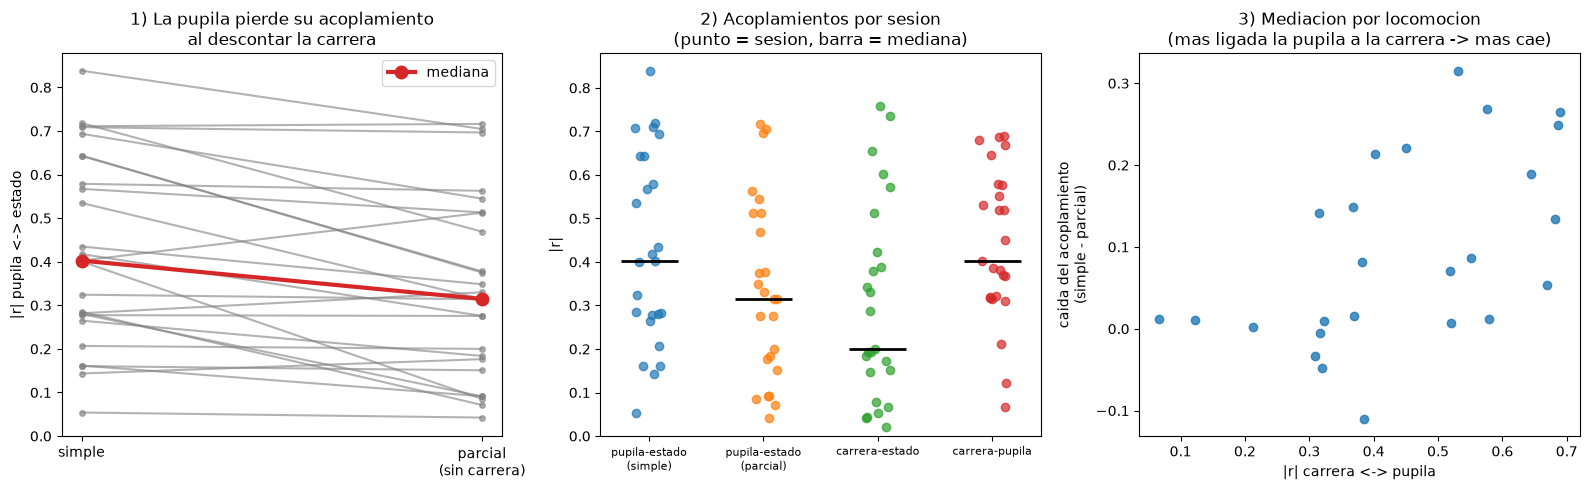

In [11]:
if n >= 2:
    rng_j = np.random.default_rng(0)
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # (1) simple vs parcial, lineas emparejadas por sesion
    ax = axes[0]
    for rs, rp in zip(r_simple, r_partial):
        ax.plot([0, 1], [rs, rp], "-o", color="gray", alpha=0.6, ms=4)
    ax.plot([0, 1], [np.median(r_simple), np.median(r_partial)], "-o", color="tab:red", lw=3,
            ms=9, label="mediana")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["simple", "parcial\n(sin carrera)"])
    ax.set_ylabel("|r| pupila <-> estado"); ax.set_ylim(bottom=0)
    ax.set_title("1) La pupila pierde su acoplamiento\nal descontar la carrera"); ax.legend()

    # (2) distribucion de |r| de los cuatro acoplamientos
    ax = axes[1]
    cats = [("pupila-estado\n(simple)", validas["r_simple"]),
            ("pupila-estado\n(parcial)", validas["r_partial"]),
            ("carrera-estado", validas["r_run_pc1"]),
            ("carrera-pupila", validas["r_run_pupil"])]
    for i, (lab, vals) in enumerate(cats):
        x = i + rng_j.uniform(-0.12, 0.12, len(vals))
        ax.scatter(x, vals, alpha=0.7)
        ax.hlines(np.median(vals), i - 0.25, i + 0.25, color="black", lw=2)
    ax.set_xticks(range(len(cats))); ax.set_xticklabels([c[0] for c in cats], fontsize=8)
    ax.set_ylabel("|r|"); ax.set_ylim(bottom=0)
    ax.set_title("2) Acoplamientos por sesion\n(punto = sesion, barra = mediana)")

    # (3) mediacion: cuanto cae el acoplamiento vs cuanto se acopla pupila-carrera
    ax = axes[2]
    caida = validas["r_simple"] - validas["r_partial"]
    ax.scatter(validas["r_run_pupil"], caida, alpha=0.8)
    ax.set_xlabel("|r| carrera <-> pupila")
    ax.set_ylabel("caida del acoplamiento\n(simple - parcial)")
    ax.set_title("3) Mediacion por locomocion\n(mas ligada la pupila a la carrera -> mas cae)")
    plt.tight_layout(); plt.show()

### 5.2 Decoding de grupo (GLM / GRU)

El *decoding* refuerza el análisis de correlación con un modelo **predictivo** (fuera de muestra).
Comparamos, por sesión, la capacidad de reconstruir el estado desde: la **pupila** (GLM y GRU), la
**carrera** (GLM) y la **pupila descontada la carrera** (GLM, control parcial). Si a nivel de grupo la
carrera decodifica **mejor** que la pupila, y la pupila **pierde** poder al quitar la carrera, se
confirma —también con un modelo predictivo— que el aparente vínculo pupila↔estado es locomoción.

In [12]:
dec = validas.dropna(subset=["dec_r_glm"]) if "dec_r_glm" in validas.columns else pd.DataFrame()
nd = len(dec)
if nd >= 2:
    med = lambda c: dec[c].median() if c in dec.columns else float("nan")
    print(f"N sesiones con decoding = {nd}\n")
    print("Mediana de r (pred<->real, pico sobre tau):")
    print(f"  pupila  -> estado  GLM: {med('dec_r_glm'):.3f}   GRU: {med('dec_r_gru'):.3f}")
    print(f"  carrera -> estado  GLM: {med('dec_r_run_glm'):.3f}")
    print(f"  pupila  -> estado  GLM (parcial, sin carrera): {med('dec_r_glm_partial'):.3f}\n")

    if {"dec_r_run_glm", "dec_r_glm"} <= set(dec.columns):
        d = dec.dropna(subset=["dec_r_run_glm", "dec_r_glm"])
        try:
            _, p = wilcoxon(d["dec_r_run_glm"], d["dec_r_glm"], alternative="greater")
            print(f"Carrera decodifica MEJOR que pupila (Wilcoxon, H1: carrera>pupila): p={p:.4f}")
        except ValueError:
            print("Carrera vs pupila: Wilcoxon no aplicable (pocas diferencias).")
    if {"dec_r_glm_partial", "dec_r_glm"} <= set(dec.columns):
        d = dec.dropna(subset=["dec_r_glm_partial", "dec_r_glm"])
        try:
            _, p = wilcoxon(d["dec_r_glm"], d["dec_r_glm_partial"], alternative="greater")
            print(f"Pupila decodifica PEOR al quitar carrera (Wilcoxon, H1: simple>parcial): p={p:.4f}")
        except ValueError:
            print("Simple vs parcial: Wilcoxon no aplicable.")
else:
    print("Sin decoding suficiente. Activa RUN_DECODING y re-ejecuta la seccion 4.")

N sesiones con decoding = 25

Mediana de r (pred<->real, pico sobre tau):
  pupila  -> estado  GLM: 0.282   GRU: 0.273
  carrera -> estado  GLM: 0.203
  pupila  -> estado  GLM (parcial, sin carrera): 0.238

Carrera decodifica MEJOR que pupila (Wilcoxon, H1: carrera>pupila): p=0.9742
Pupila decodifica PEOR al quitar carrera (Wilcoxon, H1: simple>parcial): p=0.1205


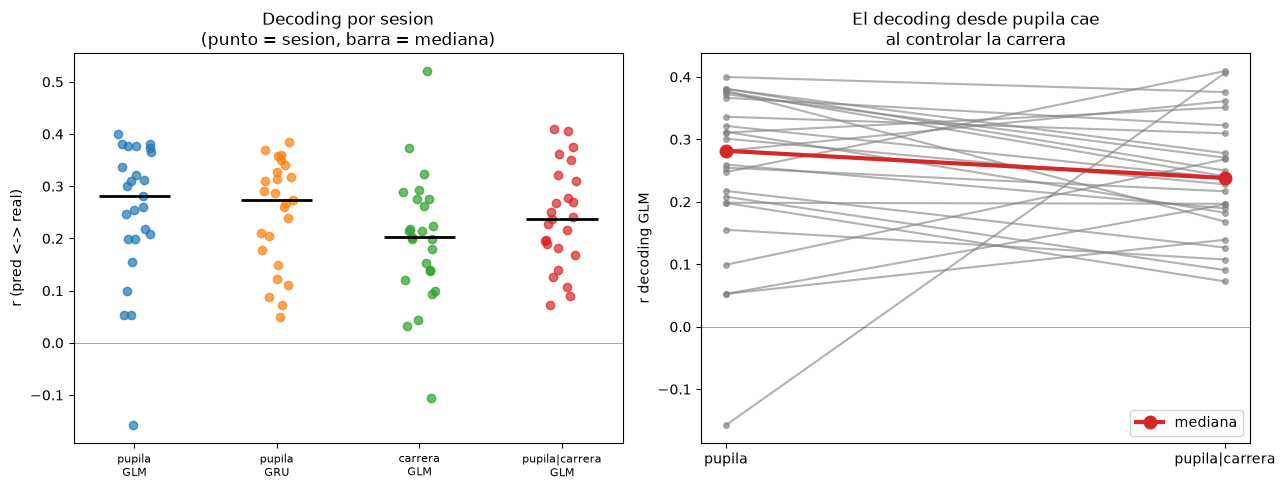

In [13]:
if nd >= 2:
    rj = np.random.default_rng(1)
    fig, (a, b) = plt.subplots(1, 2, figsize=(13, 5))

    cats = [("pupila\nGLM", "dec_r_glm"), ("pupila\nGRU", "dec_r_gru"),
            ("carrera\nGLM", "dec_r_run_glm"), ("pupila|carrera\nGLM", "dec_r_glm_partial")]
    for i, (lab, col) in enumerate(cats):
        if col in dec.columns:
            v = dec[col].dropna().values
            a.scatter(i + rj.uniform(-0.12, 0.12, len(v)), v, alpha=0.7)
            if len(v): a.hlines(np.median(v), i - 0.25, i + 0.25, color="black", lw=2)
    a.set_xticks(range(len(cats))); a.set_xticklabels([c[0] for c in cats], fontsize=8)
    a.axhline(0, color="black", lw=0.6, alpha=0.4); a.set_ylabel("r (pred <-> real)")
    a.set_title("Decoding por sesion\n(punto = sesion, barra = mediana)")

    if {"dec_r_glm", "dec_r_glm_partial"} <= set(dec.columns):
        for rs, rp in zip(dec["dec_r_glm"], dec["dec_r_glm_partial"]):
            b.plot([0, 1], [rs, rp], "-o", color="gray", alpha=0.6, ms=4)
        b.plot([0, 1], [dec["dec_r_glm"].median(), dec["dec_r_glm_partial"].median()],
               "-o", color="tab:red", lw=3, ms=9, label="mediana")
        b.set_xticks([0, 1]); b.set_xticklabels(["pupila", "pupila|carrera"])
        b.set_ylabel("r decoding GLM"); b.axhline(0, color="black", lw=0.6, alpha=0.4)
        b.set_title("El decoding desde pupila cae\nal controlar la carrera"); b.legend()
    plt.tight_layout(); plt.show()

---
## 6. Interpretación de grupo

<div class="alert alert-success">
<b>Cómo leer el resultado (rellenar con tus números)</b><br>
<ul><li>Si el <b>Wilcoxon</b> da <code>p&lt;0.05</code> (simple &gt; parcial) y la fracción de sesiones con parcial significativo es <b>~azar</b> → <b>la pupila no indexa el estado más allá de la locomoción</b>, de forma consistente entre ratones. El hallazgo de sesión única generaliza.</li><li>Si <b>carrera↔estado</b> es significativo en casi todas las sesiones (|r| mediano alto) → <b>la locomoción domina el estado de VISp</b> a nivel de población.</li><li>Si en cambio muchas sesiones mantienen un <b>parcial</b> significativo → habría un acoplamiento pupila-cortex independiente de la carrera que merece más análisis.</li></ul>
</div>

### Límites
- **Control de carrera lineal y contemporáneo:** no descarta efectos retardados/no lineales de la locomoción.
- **Una modalidad (Neuropixels) y un dataset (Allen):** no generaliza a otras áreas/estados.
- **PC1 como resumen del estado:** en espontáneo captura poca varianza; otras definiciones podrían diferir.
- **Sesiones heterogéneas:** distinto nº de unidades, calidad de eye-tracking y de la señal de carrera
  (con artefactos). Spearman mitiga los atípicos, pero conviene depurar para un análisis definitivo.

---
## 7. (Opcional) Extensión: modulación de respuestas a *drifting gratings*

<div class="alert alert-info">
<b>Cambia la pregunta.</b> Con estímulo, VISp está dominada por respuestas <b>evocadas</b>, así que ya no
preguntamos "¿la pupila indexa el estado espontáneo?" sino <b>"¿el arousal/locomoción MODULA las
respuestas visuales?"</b> (Niell &amp; Stryker 2010; McGinley 2015). Lo hacemos <b>por <i>trial</i></b>:
resumimos cada presentación por su respuesta poblacional, su pupila y su carrera, y <b>descontamos la
condición del estímulo</b> (orientación × frecuencia) antes de correlacionar — así separamos "modulación
de estado" de "respuesta al estímulo". Seguimos <b>controlando la carrera</b>.
</div>

Es un **template para una sola sesión** (la primera válida); escalarlo a grupo es análogo a las §3–§5.

In [14]:
def analizar_gratings(row):
    # Correlaciones de "ruido" trial-a-trial: respuesta<->pupila y respuesta<->carrera, residualizando
    # por condicion de estimulo y controlando carrera. Devuelve dict.
    rem = remfile.File(row["url"]); h5 = h5py.File(rem, "r")
    io = pynwb.NWBHDF5IO(file=h5, load_namespaces=True); nwb = io.read()
    try:
        key = "drifting_gratings_presentations"
        if key not in nwb.intervals:
            return {"session": row["session"], "status": "sin_gratings"}
        dg = nwb.intervals[key].to_dataframe().reset_index(drop=True)
        cond_cols = [c for c in ["orientation", "temporal_frequency", "contrast"] if c in dg.columns]

        # Unidades VISp + QC (mismo criterio)
        cols = [c for c in ["peak_channel_id","quality","isi_violations","amplitude_cutoff",
                            "presence_ratio"] if c in nwb.units.colnames]
        um = pd.DataFrame({c: nwb.units[c].data[:] for c in cols}, index=nwb.units.id[:])
        elec = nwb.electrodes.to_dataframe(); um["location"] = um["peak_channel_id"].map(elec["location"])
        if "quality" in um: um["quality"] = um["quality"].astype(str)
        mask = um["location"] == REGION
        if "quality" in um:          mask &= um["quality"] == QC_QUALITY
        if "isi_violations" in um:   mask &= um["isi_violations"] <= QC_ISI_MAX
        if "amplitude_cutoff" in um: mask &= um["amplitude_cutoff"] <= QC_AMP_CUTOFF_MAX
        if "presence_ratio" in um:   mask &= um["presence_ratio"] >= QC_PRESENCE_MIN
        pos = np.where(mask.values)[0]; sel = um[mask]
        if len(pos) < MIN_UNITS_PCA:
            return {"session": row["session"], "status": "pocas_unidades"}

        starts = dg["start_time"].values; stops = dg["stop_time"].values
        durs = stops - starts; n_tr = len(dg)
        # Matriz respuesta (trials x unidades): tasa media por trial (busqueda binaria sobre spike_times)
        R = np.zeros((n_tr, len(pos)))
        for j, p in enumerate(pos):
            st = np.sort(np.asarray(nwb.units["spike_times"][p]))
            lo = np.searchsorted(st, starts); hi = np.searchsorted(st, stops)
            R[:, j] = (hi - lo) / durs
        # Pupila y carrera medias por trial
        po = nwb.processing["filtered_gaze_mapping"]["pupil_area"]
        pv = np.asarray(po.data[:], float); pt = np.asarray(po.timestamps[:], float)
        m = ~np.isnan(pv); pv = np.interp(pt, pt[m], pv[m])
        def media_por_trial(t, v):
            lo = np.searchsorted(t, starts); hi = np.searchsorted(t, stops)
            return np.array([v[a:b].mean() if b > a else np.nan for a, b in zip(lo, hi)])
        pup_tr = media_por_trial(pt, pv)
        carrera, _ = cargar_carrera(nwb)
        run_tr = media_por_trial(np.asarray(carrera.t), np.asarray(carrera.d)) if carrera is not None else None

        # Estado por trial = PC1 de la matriz de respuestas (z-score por unidad)
        Rz = StandardScaler().fit_transform(R)
        pc1 = PCA(n_components=1).fit_transform(Rz)[:, 0]

        # Residualizar por condicion (quita el estimulo y, en pupila, el nivel por condicion)
        dfc = dg[cond_cols].astype(str).agg("|".join, axis=1) if cond_cols else pd.Series(["all"]*n_tr)
        def residual_por_condicion(x):
            s = pd.Series(x); return (s - s.groupby(dfc.values).transform("mean")).values
        ok = ~np.isnan(pup_tr)
        if run_tr is not None: ok &= ~np.isnan(run_tr)
        pc1_r = residual_por_condicion(pc1)[ok]
        pup_r = residual_por_condicion(pup_tr)[ok]
        from scipy.stats import spearmanr
        out = {"session": row["session"], "status": "ok", "n_trials": int(ok.sum()),
               "n_cond": int(dfc.nunique())}
        out["r_pupil_noise"] = float(spearmanr(pc1_r, pup_r).correlation)
        if run_tr is not None:
            run_r = residual_por_condicion(run_tr)[ok]
            out["r_run_noise"] = float(spearmanr(pc1_r, run_r).correlation)
            # parcial pupila<->estado controlando carrera (a nivel de residuos de condicion)
            e_pc1 = quitar_carrera(pc1_r, run_r); e_pup = quitar_carrera(pup_r, run_r)
            out["r_pupil_partial_noise"] = float(spearmanr(e_pc1, e_pup).correlation)
        return out
    except Exception as e:
        return {"session": row["session"], "status": f"error: {type(e).__name__}: {e}"}
    finally:
        io.close(); h5.close(); rem.close()

# Demo en la primera sesion valida (si ya corriste la seccion 4)
try:
    fila_demo = validas.iloc[0] if len(validas) else df_sessions.iloc[0]
    print("Gratings (demo) en sesion:", fila_demo["session"])
    print(analizar_gratings(fila_demo))
except Exception as e:
    print("Ejecuta antes la seccion 4, o revisa:", e)

Gratings (demo) en sesion: 744228101.nwb
Ejecuta antes la seccion 4, o revisa: 'url'


<div class="alert alert-info">
<b>Cómo leer las correlaciones de ruido</b><br>
<code>r_pupil_noise</code> y <code>r_run_noise</code> son correlaciones <i>trial-a-trial</i> tras quitar el estímulo. <code>r_pupil_partial_noise</code> es pupila↔respuesta descontando la carrera. Si el parcial ≈ 0 mientras <code>r_run_noise</code> es alto → también en las respuestas evocadas la locomoción es la que manda, coherente con el espontáneo. Para pasar a grupo, envuelve esto en un bucle como el de la §4.
</div>

---
## 8. Referencias

- Siegle, J. H., et al. (2021). *Survey of spiking in the mouse visual system reveals functional
  hierarchy.* **Nature** 592, 86–92. (Allen Visual Coding – Neuropixels; DANDI:000021.)
- de Vries, S. E. J., et al. (2020). *A large-scale standardized physiological survey reveals functional
  organization of the mouse visual cortex.* **Nature Neuroscience** 23, 138–151.
- Niell, C. M., & Stryker, M. P. (2010). *Modulation of visual responses by behavioral state in mouse
  visual cortex.* **Neuron** 65, 472–479.
- McGinley, M. J., et al. (2015). *Waking state: rapid variations modulate neural and behavioral
  responses.* **Neuron** 87, 1143–1161.
- Vinck, M., et al. (2015). *Arousal and locomotion make distinct contributions to cortical activity
  patterns and visual encoding.* **Neuron** 86, 740–754.
- Stringer, C., et al. (2019). *Spontaneous behaviors drive multidimensional, brainwide activity.*
  **Science** 364, 255.
- Musall, S., et al. (2019). *Single-trial neural dynamics are dominated by richly varied movements.*
  **Nature Neuroscience** 22, 1677–1686.
- **OpenScope Databook** — Allen Institute. https://alleninstitute.github.io/openscope_databook/
- **pynapple** — Viejo, G., et al. (2023). *eLife.*